# Predict β/α Ratio


In [128]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.signal import savgol_filter
from scipy.optimize import lsq_linear
from scipy.interpolate import interp1d
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor


In [129]:
class MultiHeadSelfAttention1D(nn.Module):
    def __init__(self, d_model: int, n_heads: int = 4) -> None:
        super().__init__()
        self.n_heads = n_heads
        self.d_model = d_model
        self.qkv_proj = nn.Linear(d_model, d_model * 3)
        self.fc_out = nn.Linear(d_model, d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len, hidden_dim = x.shape
        head_dim = hidden_dim // self.n_heads

        qkv = (
            self.qkv_proj(x)
            .reshape(batch_size, seq_len, 3, self.n_heads, head_dim)
            .permute(2, 0, 3, 1, 4)
        )
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) / np.sqrt(head_dim)
        attn = attn.softmax(dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(batch_size, seq_len, hidden_dim)
        out = self.fc_out(out)
        return self.norm(out + x)


class EarlyFusionNet(nn.Module):
    def __init__(self, input_spec_len: int, input_feat_len: int) -> None:
        super().__init__()
        self.cnn_branch = nn.Sequential(
            nn.Conv1d(1, 128, 11, padding=5),
            nn.ReLU(),
            nn.Conv1d(128, 256, 7, padding=3),
            nn.ReLU(),
            nn.Conv1d(256, 512, 5, padding=2),
            nn.ReLU(),
            nn.Conv1d(512, 512, 3, padding=1),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(32)
        self.attn = MultiHeadSelfAttention1D(512, n_heads=4)
        self.flatten = nn.Flatten()
        self.cnn_fc = nn.Sequential(
            nn.Linear(512 * 32, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
        )
        self.mlp_branch = nn.Sequential(
            nn.Linear(input_feat_len, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
        )
        self.fusion = nn.Sequential(
            nn.Linear(64 + 16, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, spec: torch.Tensor, feat: torch.Tensor) -> torch.Tensor:
        x = self.cnn_branch(spec)
        x = self.pool(x)
        x = x.permute(0, 2, 1)
        x = self.attn(x)
        x = x.permute(0, 2, 1)
        x = self.flatten(x)
        x = self.cnn_fc(x)
        y = self.mlp_branch(feat)
        out = torch.cat([x, y], dim=1)
        return self.fusion(out)


In [130]:
COMPONENT_ORDER = ["alpha_helix", "beta_sheet", "beta_turn", "other_peaks"]


def extract_integral_features(
    spectrum: np.ndarray,
    wavenumber_axis: np.ndarray,
    peak_table_flat,
    delta: float = 2.0,
) -> np.ndarray:
    features = []
    for _, center in peak_table_flat:
        mask = (wavenumber_axis >= center - delta) & (wavenumber_axis <= center + delta)
        if np.any(mask):
            peak_region = spectrum[mask]
            if len(peak_region) > 0:
                integral = peak_region.sum()
                max_val = peak_region.max()
                min_val = peak_region.min()
                mean_val = peak_region.mean()
                median_val = np.median(peak_region)
                var_val = peak_region.var()
                std_val = peak_region.std()
                if len(peak_region) >= 3 and std_val > 0:
                    skewness = ((peak_region - mean_val) ** 3).mean() / (std_val ** 3)
                    kurtosis = ((peak_region - mean_val) ** 4).mean() / (std_val ** 4)
                else:
                    skewness = 0.0
                    kurtosis = 0.0
                peak_features = [
                    integral,
                    max_val,
                    min_val,
                    mean_val,
                    median_val,
                    var_val,
                    std_val,
                    skewness,
                    kurtosis,
                ]
            else:
                peak_features = [0.0] * 9
        else:
            peak_features = [0.0] * 9
        features.extend(peak_features)
    return np.array(features)


def detect_peaks(
    y: np.ndarray,
    x_axis: np.ndarray,
    threshold: float = 0.2,
    window: int = 20,
    min_distance: int = 50,
):
    y_smooth = savgol_filter(y, window_length=21, polyorder=3)
    dy = np.gradient(y_smooth)
    d2y = np.gradient(dy)
    candidates = []
    for i in range(1, len(y_smooth) - 1):
        if dy[i - 1] > 0 and dy[i + 1] < 0 and d2y[i] < 0 and y_smooth[i] > threshold:
            candidates.append(i)
    filtered = []
    for idx in candidates:
        left = max(0, idx - window)
        right = min(len(y_smooth), idx + window)
        if y_smooth[idx] == np.max(y_smooth[left:right]):
            filtered.append(idx)
    final = []
    last_idx = -min_distance
    for idx in filtered:
        if idx - last_idx >= min_distance:
            final.append(idx)
            last_idx = idx
    return np.array(final, dtype=int), y_smooth


def classify_peak(peak_wavenumber, peak_table, delta_multiplier: float = 1.2):
    for family, peaks in peak_table.items():
        for center, delta, gamma in peaks:
            wide_delta = max(delta, 1.5) * delta_multiplier
            if abs(peak_wavenumber - center) <= wide_delta:
                return family, gamma
    return None, None


def lorentzian(x, x0, gamma):
    return 1 / (1 + ((x - x0) / (gamma / 2)) ** 2)


def lorentzian_area(amplitude, gamma):
    return np.pi * gamma * amplitude / 2


def extract_decomposed_spectra_features(
    components: dict,
    component_order,
    wavenumber_axis: np.ndarray,
    peak_table_flat,
    delta: float = 2.0,
) -> np.ndarray:
    if not components:
        return np.zeros((0, len(peak_table_flat) * 9 * len(component_order)))
    num_samples = len(next(iter(components.values())))
    features = []
    for idx in range(num_samples):
        sample_features = []
        for key in component_order:
            spectrum = components[key][idx]
            sample_features.extend(
                extract_integral_features(spectrum, wavenumber_axis, peak_table_flat, delta)
            )
        features.append(sample_features)
    return np.asarray(features, dtype=np.float32)


def extract_peak_detection_features(
    spectra: np.ndarray,
    wavenumber_axis: np.ndarray,
    peak_table,
    max_peaks: int = 15,
) -> np.ndarray:
    features = []
    for spectrum in spectra:
        sample_features = []
        peak_indices, _ = detect_peaks(
            spectrum,
            wavenumber_axis,
            threshold=0.1,
            window=15,
            min_distance=30,
        )
        if len(peak_indices) > 0:
            detected_positions = wavenumber_axis[peak_indices]
            detected_amplitudes = spectrum[peak_indices]
            n_peaks = min(len(detected_positions), max_peaks)
            for i in range(max_peaks):
                if i < n_peaks:
                    pos = (detected_positions[i] - wavenumber_axis.min()) / (
                        wavenumber_axis.max() - wavenumber_axis.min()
                    )
                    amp = detected_amplitudes[i] / max(np.max(np.abs(spectrum)), 1e-8)
                    peak_type, _ = classify_peak(detected_positions[i], peak_table)
                    type_encoding = [0, 0, 0, 0]
                    if peak_type == "alpha_helix":
                        type_encoding[0] = 1
                    elif peak_type == "beta_sheet":
                        type_encoding[1] = 1
                    elif peak_type == "beta_turn":
                        type_encoding[2] = 1
                    else:
                        type_encoding[3] = 1
                    peak_features = [pos, amp] + type_encoding
                else:
                    peak_features = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
                sample_features.extend(peak_features)
        else:
            sample_features.extend([0.0] * (max_peaks * 6))
        features.append(sample_features)
    return np.asarray(features, dtype=np.float32)


def extract_nnls_fitting_features(
    spectrum: np.ndarray,
    wavenumber_axis: np.ndarray,
    peak_table,
    gamma_width: int = 31,
    return_details: bool = False,
):
    peak_indices, _ = detect_peaks(spectrum, wavenumber_axis, threshold=0.2, window=20, min_distance=50)
    if len(peak_indices) > 0:
        peak_indices = peak_indices.astype(int)
        detected_positions = wavenumber_axis[peak_indices]
    else:
        detected_positions = np.array([])

    selected_centers, selected_types, selected_gammas = [], [], []
    for p in detected_positions:
        fam, gamma = classify_peak(p, peak_table)
        if fam is not None:
            selected_centers.append(p)
            selected_types.append(fam)
            selected_gammas.append(gamma if gamma is not None else gamma_width)

    selected_centers = np.array(selected_centers)
    selected_types = np.array(selected_types)
    selected_gammas = np.array(selected_gammas)

    total_features = 12 * 7 + 7
    features = np.zeros(total_features, dtype=np.float32)
    details = None

    if len(selected_centers) == 0:
        if return_details:
            details = {
                "components": {
                    name: np.zeros_like(spectrum, dtype=np.float32) for name in COMPONENT_ORDER
                },
                "positions": np.array([], dtype=np.float32),
                "types": np.array([], dtype=object),
                "gammas": np.array([], dtype=np.float32),
                "amplitudes": np.array([], dtype=np.float32),
            }
            return features, details
        return features

    B = np.stack([lorentzian(wavenumber_axis, c, g) for c, g in zip(selected_centers, selected_gammas)], axis=1)
    B /= np.maximum(B.max(axis=0, keepdims=True), 1e-12)
    res = lsq_linear(B, spectrum, bounds=(0, np.inf), lsq_solver="exact")
    amplitudes = res.x.astype(np.float32)

    recon = B @ amplitudes
    residuals = spectrum - recon
    mse = float(np.mean(residuals ** 2))
    ss_tot = float(np.sum((spectrum - np.mean(spectrum)) ** 2))
    ss_res = float(np.sum(residuals ** 2))
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0

    areas = lorentzian_area(amplitudes, selected_gammas.astype(np.float32))

    for i, (center, amp, area, gamma, peak_type) in enumerate(
        zip(selected_centers, amplitudes, areas, selected_gammas, selected_types)
    ):
        if i >= 12:
            break
        peak_features = [float(amp), float(area), float(center), float(gamma)]
        type_encoding = [0.0, 0.0, 0.0]
        if peak_type == "alpha_helix":
            type_encoding[0] = 1.0
        elif peak_type == "beta_sheet":
            type_encoding[1] = 1.0
        elif peak_type == "beta_turn":
            type_encoding[2] = 1.0
        peak_features.extend(type_encoding)
        start_idx = i * 7
        features[start_idx:start_idx + 7] = peak_features

    global_features = [
        mse,
        r_squared,
        float(len(selected_centers)),
        float(np.mean(amplitudes)) if len(amplitudes) else 0.0,
        float(np.std(amplitudes)) if len(amplitudes) else 0.0,
        float(np.mean(areas)) if len(areas) else 0.0,
        float(np.std(areas)) if len(areas) else 0.0,
    ]
    features[-7:] = global_features

    if return_details:
        component_spectra = {name: np.zeros_like(spectrum, dtype=np.float32) for name in COMPONENT_ORDER}
        for col_idx, peak_type in enumerate(selected_types):
            contribution = B[:, col_idx] * amplitudes[col_idx]
            if peak_type in component_spectra:
                component_spectra[peak_type] += contribution.astype(np.float32)
            else:
                component_spectra["other_peaks"] += contribution.astype(np.float32)
        details = {
            "components": component_spectra,
            "positions": selected_centers.astype(np.float32),
            "types": selected_types,
            "gammas": selected_gammas.astype(np.float32),
            "amplitudes": amplitudes,
        }
        return features, details

    return features


In [131]:
import os

BASE_DIR = os.getcwd()
MODEL_PATH = os.path.join(
    "..",
    "models",
    "best_early_fusion_model_4PCA_1360-1800.pth",
)
SPECTRUM_PATH = os.path.join(
    "..",
    "data",
    "Vera0925",
    "preprocessed",
    "1360-1800-5-8_smoothed.txt",
)

print(f"Model path: {os.path.abspath(MODEL_PATH)}")
print(f"Spectrum path: {os.path.abspath(SPECTRUM_PATH)}")


Model path: /Users/weianqi/Desktop/Photothermal Spectroscopy Deconvolution/spectral segmentation/spectral_segmentation/secondary_protein_deconvolution/models/best_early_fusion_model_4PCA_1360-1800.pth
Spectrum path: /Users/weianqi/Desktop/Photothermal Spectroscopy Deconvolution/spectral segmentation/spectral_segmentation/secondary_protein_deconvolution/data/Vera0925/preprocessed/1360-1800-5-8_smoothed.txt


In [132]:
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Model file not found at {MODEL_PATH}. Please update MODEL_PATH to the correct location."
    )

checkpoint = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
print("Checkpoint keys:", list(checkpoint.keys()))

model_config = checkpoint["model_config"]
mean_spec = checkpoint["mean_spec"]
std_spec = checkpoint["std_spec"]
wavenumber_axis = checkpoint["wavenumber_axis"]
peak_table_flat = checkpoint["peak_table_flat"]
peak_table = checkpoint["peak_table"]

feature_mean = checkpoint["feature_mean"]
feature_std  = checkpoint["feature_std"]

feature_scaler = checkpoint.get("feature_scaler")
feature_pca = checkpoint.get("feature_pca")
feature_scaler_mean = checkpoint.get("feature_scaler_mean")
feature_scaler_scale = checkpoint.get("feature_scaler_scale")
feature_pca_components = checkpoint.get("feature_pca_components")
feature_pca_mean = checkpoint.get("feature_pca_mean")

print("Loaded checkpoint metadata:")
print(f"  spectral length: {model_config['input_spec_len']}")
print(f"  feature length: {model_config['input_feat_len']}")
print(
    f"  wavenumber range: {wavenumber_axis.min():.1f} – {wavenumber_axis.max():.1f} cm⁻¹"
)
print("Feature transforms available:")
print(f"  feature_scaler: {type(feature_scaler).__name__ if feature_scaler is not None else None}")
print(f"  feature_pca: {type(feature_pca).__name__ if feature_pca is not None else None}")
print(
    f"  feature_scaler_mean: {'set' if feature_scaler_mean is not None else 'None'}, "
    f"feature_scaler_scale: {'set' if feature_scaler_scale is not None else 'None'}"
)
print(
    f"  feature_pca_components: {'set' if feature_pca_components is not None else 'None'}, "
    f"feature_pca_mean: {'set' if feature_pca_mean is not None else 'None'}"
)


Checkpoint keys: ['model_state_dict', 'optimizer_state_dict', 'train_losses', 'val_losses', 'mean_spec', 'std_spec', 'feature_mean', 'feature_std', 'wavenumber_axis', 'peak_table_flat', 'peak_table', 'dataset_info', 'feature_info', 'model_config']
Loaded checkpoint metadata:
  spectral length: 441
  feature length: 100
  wavenumber range: 1360.0 – 1800.0 cm⁻¹
Feature transforms available:
  feature_scaler: None
  feature_pca: None
  feature_scaler_mean: None, feature_scaler_scale: None
  feature_pca_components: None, feature_pca_mean: None


In [133]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def build_model_from_config(cfg: dict) -> nn.Module:
    arch = cfg.get("architecture", "EarlyFusionNet")
    if arch in ("EarlyFusionNet_with_MultiHeadAttention", "EarlyFusionNet"):
        return EarlyFusionNet(
            input_spec_len=cfg["input_spec_len"],
            input_feat_len=cfg["input_feat_len"],
        )
    raise ValueError(f"Unknown architecture: {arch}")

model = build_model_from_config(model_config).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Model loaded to {device}")


Model loaded to cpu


In [134]:
DATASET_CANDIDATES = [
    os.path.join("..", "data", "dataset3.npz"),
]

PCA_COMPONENTS = None
PCA_MEAN = None
SELECTED_PCA_INDICES = None
TRAIN_FEATURE_MEAN = None
TRAIN_FEATURE_STD = None
TRAIN_RATIO_LOG = None
FEATURE_TRANSFORM_CACHE = os.path.join(
    "..",
    "models",
    "model_results_dataset3.npz",
)
COMPONENT_ORDER = ["alpha_helix", "beta_sheet", "beta_turn", "other_peaks"]


def _resolve_dataset_path(candidates=None):
    for path in candidates or DATASET_CANDIDATES:
        if os.path.exists(path):
            return path
    raise FileNotFoundError("Could not locate dataset3 file for feature transform preparation")


def calculate_area_ratio_from_decomposed(components, wavenumber_axis):
    area_fn = getattr(np, "trapezoid", np.trapz)
    alpha = components["alpha_helix"]
    beta_sheet = components["beta_sheet"]
    beta_turn = components["beta_turn"]
    ratios = []
    for idx in range(alpha.shape[0]):
        alpha_area = area_fn(alpha[idx], wavenumber_axis)
        beta_area = area_fn(beta_sheet[idx], wavenumber_axis) + area_fn(beta_turn[idx], wavenumber_axis)
        ratios.append(beta_area / alpha_area if alpha_area > 1e-8 else 0.0)
    return np.asarray(ratios, dtype=np.float32)


def prepare_feature_transform(force: bool = False):
    global PCA_COMPONENTS, PCA_MEAN, SELECTED_PCA_INDICES, TRAIN_FEATURE_MEAN, TRAIN_FEATURE_STD, TRAIN_RATIO_LOG
    if (
        not force
        and PCA_COMPONENTS is not None
        and PCA_MEAN is not None
        and SELECTED_PCA_INDICES is not None
        and TRAIN_FEATURE_MEAN is not None
        and TRAIN_FEATURE_STD is not None
    ):
        return

    if os.path.exists(FEATURE_TRANSFORM_CACHE):
        cache = np.load(FEATURE_TRANSFORM_CACHE)
        required_keys = {
            "pca_components",
            "pca_mean",
            "selected_indices",
            "feature_mean",
            "feature_std",
        }
        missing_keys = [key for key in required_keys if key not in cache.files]
        if missing_keys:
            raise KeyError(
                f"Feature-transform cache {FEATURE_TRANSFORM_CACHE} missing {missing_keys},"
                "Please make sure the traning transcipt is saved."
            )
        
        PCA_COMPONENTS        = cache["pca_components"].astype(np.float32)
        PCA_MEAN              = cache["pca_mean"].astype(np.float32)
        SELECTED_PCA_INDICES  = cache["selected_indices"].astype(np.int32)
        TRAIN_FEATURE_MEAN    = cache["feature_mean"].astype(np.float32)
        TRAIN_FEATURE_STD     = cache["feature_std"].astype(np.float32)
        TRAIN_RATIO_LOG       = cache["y_log"].astype(np.float32) if "y_log" in cache.files else None
        cache.close()
        print(f"Loaded feature transform from cache: {FEATURE_TRANSFORM_CACHE}")
        return



prepare_feature_transform(force=False)


Loaded feature transform from cache: ../models/model_results_dataset3.npz


In [ ]:
def _transform_features(combined_features: np.ndarray) -> np.ndarray:
    if combined_features.ndim == 1:
        combined_features = combined_features.reshape(1, -1)
    centered = combined_features - PCA_MEAN
    pca_features = centered @ PCA_COMPONENTS.T
    selected = pca_features[:, SELECTED_PCA_INDICES]
    
    mean_ref = feature_mean if "feature_mean" in globals() else TRAIN_FEATURE_MEAN
    std_ref  = feature_std  if "feature_std"  in globals() else TRAIN_FEATURE_STD
    standardized = (selected - mean_ref) / std_ref
    
    standardized = np.nan_to_num(standardized, nan=0.0, posinf=0.0, neginf=0.0)
    standardized = np.clip(standardized, -10.0, 10.0)
    return standardized.astype(np.float32)


def predict_beta_alpha_ratio(raw_spectrum: np.ndarray) -> float:
    prepare_feature_transform(force=False)

    spectrum = raw_spectrum.astype(np.float32, copy=False)
    spectrum_norm = ((spectrum - mean_spec) / std_spec).astype(np.float32, copy=False)

    integral_features = extract_integral_features(spectrum, wavenumber_axis, peak_table_flat)
    peak_features = extract_peak_detection_features(spectrum.reshape(1, -1), wavenumber_axis, peak_table)

    nnls_features, nnls_details = extract_nnls_fitting_features(
        spectrum, wavenumber_axis, peak_table, return_details=True
    )

    component_samples = {
        key: np.expand_dims(nnls_details["components"][key], axis=0)
        for key in COMPONENT_ORDER
    }
    decomposed_features = extract_decomposed_spectra_features(
        component_samples, COMPONENT_ORDER, wavenumber_axis, peak_table_flat
    )

    combined_features = np.concatenate(
        [
            integral_features,
            decomposed_features.reshape(-1),
            peak_features.reshape(-1),
            nnls_features,
        ]
    ).astype(np.float32, copy=False)

    if combined_features.shape[0] != PCA_MEAN.shape[0]:
        raise ValueError(
            f"Combined feature length {combined_features.shape[0]} does not match PCA mean length {PCA_MEAN.shape[0]}"
        )

    transformed_features = _transform_features(combined_features)

    if transformed_features.shape[1] != model_config["input_feat_len"]:
        raise ValueError(
            f"Transformed feature dimension {transformed_features.shape[1]} ≠ training dimension {model_config['input_feat_len']}.\n"
            "Please verify that PCA components/selected_indices match the checkpoint."
        )

    spec_tensor = torch.from_numpy(spectrum_norm).unsqueeze(0).unsqueeze(0)
    feat_tensor = torch.from_numpy(transformed_features)

    spec_tensor = spec_tensor.to(device=device, dtype=torch.float32)
    feat_tensor = feat_tensor.to(device=device, dtype=torch.float32)

    with torch.no_grad():
        raw_pred = model(spec_tensor, feat_tensor).cpu().numpy()

    log_ratio = float(raw_pred[0, 0])
    log_ratio = np.clip(log_ratio, -2.0, 2.0)
    beta_alpha = float(np.expm1(log_ratio))

    return beta_alpha


In [136]:
if not os.path.exists(SPECTRUM_PATH):
    raise FileNotFoundError(
        f"Spectrum file not found at {SPECTRUM_PATH}. Please update SPECTRUM_PATH to the correct file."
    )

raw_data = np.loadtxt(SPECTRUM_PATH)
if raw_data.ndim != 2 or raw_data.shape[1] < 2:
    raise ValueError("Expected the spectrum file to contain at least two columns: wavenumber and intensity.")

raw_wavenumber_axis = raw_data[:, 0]
raw_spectrum = raw_data[:, 1]

print(
    f"Loaded spectrum with range {raw_wavenumber_axis.min():.1f} – {raw_wavenumber_axis.max():.1f} cm⁻¹"
)
print(f"Number of data points: {len(raw_wavenumber_axis)}")


FileNotFoundError: Spectrum file not found at ../data/Vera0925/preprocessed/1360-1800-5-8_smoothed.txt. Please update SPECTRUM_PATH to the correct file.

In [ ]:
overlap_min = max(wavenumber_axis.min(), raw_wavenumber_axis.min())
overlap_max = min(wavenumber_axis.max(), raw_wavenumber_axis.max())
if overlap_min >= overlap_max:
    raise ValueError("No overlapping wavenumber range between model and input spectrum.")

interp = interp1d(
    raw_wavenumber_axis,
    raw_spectrum,
    kind="linear",
    bounds_error=False,
    fill_value=0.0,
)
processed_spec = interp(wavenumber_axis)
processed_spec = np.nan_to_num(processed_spec, nan=0.0)

print("Interpolation complete.")
print(f"Processed spectrum length: {len(processed_spec)}")


Interpolation complete.
Processed spectrum length: 441


In [ ]:
beta_alpha_ratio = predict_beta_alpha_ratio(processed_spec)
print(f"Predicted β/α ratio: {beta_alpha_ratio:.4f}")

Predicted β/α ratio: 2.1374


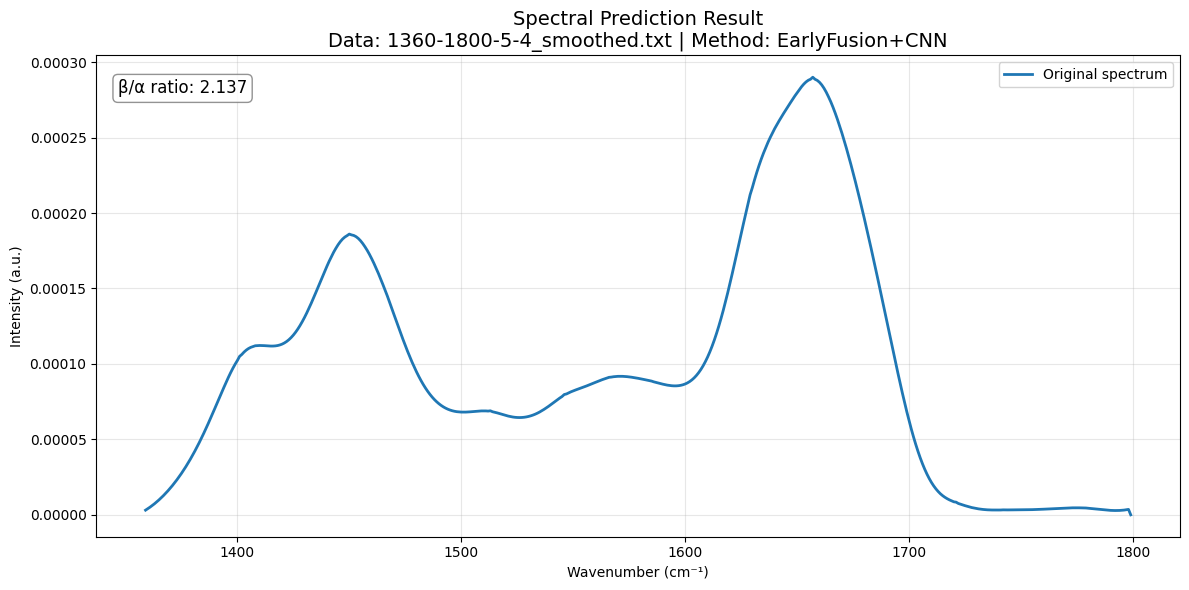

In [ ]:
spectrum_name = os.path.basename(SPECTRUM_PATH)
plt.figure(figsize=(12, 6))
plt.plot(raw_wavenumber_axis, processed_spec, color="tab:blue", lw=2, label="Original spectrum")

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Intensity (a.u.)")
plt.title(
    f"Spectral Prediction Result\nData: {spectrum_name} | Method: EarlyFusion+CNN",
    fontsize=14,
)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right", framealpha=0.85)

info_text = (
    f"β/α ratio: {beta_alpha_ratio:.3f}"
)
plt.text(
    0.02,
    0.95,
    info_text,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="gray"),
)

_current_prediction_fig = plt.gcf()
plt.tight_layout()
plt.show()


In [ ]:
SAVE_PREDICTION_FIG = True

if SAVE_PREDICTION_FIG:
    results_dir = os.path.join("..", "data", "Vera0925", "results")
    os.makedirs(results_dir, exist_ok=True)

    spectrum_stem = os.path.splitext(os.path.basename(SPECTRUM_PATH))[0]
    output_png = os.path.join(results_dir, f"{spectrum_stem}_prediction.png")

    if "_current_prediction_fig" not in globals() or _current_prediction_fig is None:
        raise RuntimeError("Visualization figure not found. Please run the plotting cell first.")

    _current_prediction_fig.savefig(output_png, dpi=300, bbox_inches="tight")
    print(f"Saved prediction plot to {os.path.abspath(output_png)}")

Saved prediction plot to /Users/weianqi/Desktop/Photothermal Spectroscopy Deconvolution/spectral segmentation/spectral_segmentation/secondary_protein_deconvolution/data/Vera0925/results/1360-1800-5-4_smoothed_prediction.png


In [ ]:
SAVE_OUTPUT = False

if SAVE_OUTPUT:
    spectrum_dir = os.path.dirname(SPECTRUM_PATH)
    spectrum_stem = os.path.splitext(os.path.basename(SPECTRUM_PATH))[0]
    OUTPUT_TXT = os.path.join(spectrum_dir, f"{spectrum_stem}_prediction.txt")
    with open(OUTPUT_TXT, "w", encoding="utf-8") as f:
        f.write("Sample\tBeta_Alpha_Ratio\n")
        f.write(f"{spectrum_stem}\t{beta_alpha_ratio:.6f}\n")
    print(f"Saved prediction to {OUTPUT_TXT}")
else:
    print("Skipped saving prediction file")



Skipped saving prediction file
